In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.funcionesTransform import *

In [2]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                18028 non-null  object 
 1   Close               18028 non-null  float64
 2   Ticker              18028 non-null  object 
 3   Monthly_Return      17550 non-null  float64
 4   Monthly_Variance    17550 non-null  float64
 5   Market_Covariance   17550 non-null  float64
 6   MarketCap           17977 non-null  float64
 7   EnterpriseValue     17977 non-null  float64
 8   PE_Trailing         17938 non-null  float64
 9   EnterpriseToEbitda  17977 non-null  float64
 10  PriceToBook         17938 non-null  float64
 11  operatingMargins    18028 non-null  float64
 12  profitMargins       17989 non-null  float64
 13  returnOnEquity      17950 non-null  float64
 14  ReturnOnAssets      17989 non-null  float64
 15  debtToEquity        17989 non-null  float64
 16  curr

# Missing Values

In [3]:
# Imputar multivariable con IterativeImputer sobre continuas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont = df.select_dtypes(include='number')

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close               18028 non-null  float64
 1   Monthly_Return      18028 non-null  float64
 2   Monthly_Variance    18028 non-null  float64
 3   Market_Covariance   18028 non-null  float64
 4   MarketCap           18028 non-null  float64
 5   EnterpriseValue     18028 non-null  float64
 6   PE_Trailing         18028 non-null  float64
 7   EnterpriseToEbitda  18028 non-null  float64
 8   PriceToBook         18028 non-null  float64
 9   operatingMargins    18028 non-null  float64
 10  profitMargins       18028 non-null  float64
 11  returnOnEquity      18028 non-null  float64
 12  ReturnOnAssets      18028 non-null  float64
 13  debtToEquity        18028 non-null  float64
 14  currentRatio        18028 non-null  float64
 15  Revenue_YoY         18028 non-null  float64
 16  Reve

In [5]:
df_imputed = pd.concat([df_cont_imputed, df.select_dtypes(exclude='number')], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close               18028 non-null  float64
 1   Monthly_Return      18028 non-null  float64
 2   Monthly_Variance    18028 non-null  float64
 3   Market_Covariance   18028 non-null  float64
 4   MarketCap           18028 non-null  float64
 5   EnterpriseValue     18028 non-null  float64
 6   PE_Trailing         18028 non-null  float64
 7   EnterpriseToEbitda  18028 non-null  float64
 8   PriceToBook         18028 non-null  float64
 9   operatingMargins    18028 non-null  float64
 10  profitMargins       18028 non-null  float64
 11  returnOnEquity      18028 non-null  float64
 12  ReturnOnAssets      18028 non-null  float64
 13  debtToEquity        18028 non-null  float64
 14  currentRatio        18028 non-null  float64
 15  Revenue_YoY         18028 non-null  float64
 16  Reve

# Transformaciones

In [6]:
# Se calculan tamaños relativos
df_transformed = calcular_relative_size(df_imputed)

In [7]:
# Se expresan columnas monetarias en billions
columnas_monetarias = ['MarketCap', 'EnterpriseValue', 'TotalAssets', 'TotalRevenue', 'TotalEquity']

for col in columnas_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [8]:
# Distribucion de variables continuas
df_transformed.describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
Close,18028.0,197.4117,411.1500,1.3880,63.1541,117.1526,217.2879,9811.7998
Monthly_Return,18028.0,0.0153,0.0962,-0.5197,-0.0394,0.0122,0.0614,1.4275
Monthly_Variance,18028.0,0.0090,0.0141,-0.0047,0.0036,0.0060,0.0099,0.3652
Market_Covariance,18028.0,0.0017,0.0015,-0.0040,0.0006,0.0014,0.0024,0.0170
MarketCap,18028.0,107.9443,348.3606,0.6997,18.3317,35.3118,77.1524,5175.0695
EnterpriseValue,18028.0,120.0539,352.7646,3.1643,23.1401,44.0006,91.2362,5175.5045
PE_Trailing,18028.0,-14.0742,1980.7838,-101202.9506,15.4220,24.2466,36.5568,5658.6473
EnterpriseToEbitda,18028.0,22.8741,91.3616,-1813.3252,11.1037,15.8756,22.2017,3204.6996
PriceToBook,18028.0,7.4060,50.8721,-1113.1821,1.8848,3.7744,8.1158,1356.5194
operatingMargins,18028.0,0.1886,0.1519,-1.5994,0.1025,0.1772,0.2576,0.9260


In [9]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew()

Close                 13.144704
Monthly_Return         1.613664
Monthly_Variance      11.544988
Market_Covariance      1.342297
MarketCap              8.292212
EnterpriseValue        8.154344
PE_Trailing          -39.429640
EnterpriseToEbitda    13.317868
PriceToBook            8.215336
operatingMargins      -0.432521
profitMargins         -1.912449
returnOnEquity         4.155181
ReturnOnAssets         0.690975
debtToEquity          -2.177221
currentRatio           6.683361
Revenue_YoY            3.993464
Revenue_QoQ            8.356580
EBITDA_YoY           -12.949636
EBITDA_QoQ           -24.281925
FCF_YoY               25.420480
FCF_QoQ               46.926445
Capex_YoY            -36.081482
Capex_QoQ            -73.339256
NetDebt_to_EBITDA      3.030180
FCF_to_EBITDA         13.746321
Capex_to_Revenue       2.862817
TotalAssets            3.693064
TotalRevenue           5.112157
TotalEquity            5.847092
RelativeAssets        48.281517
RelativeRevenue       26.446336
Relative

Cont


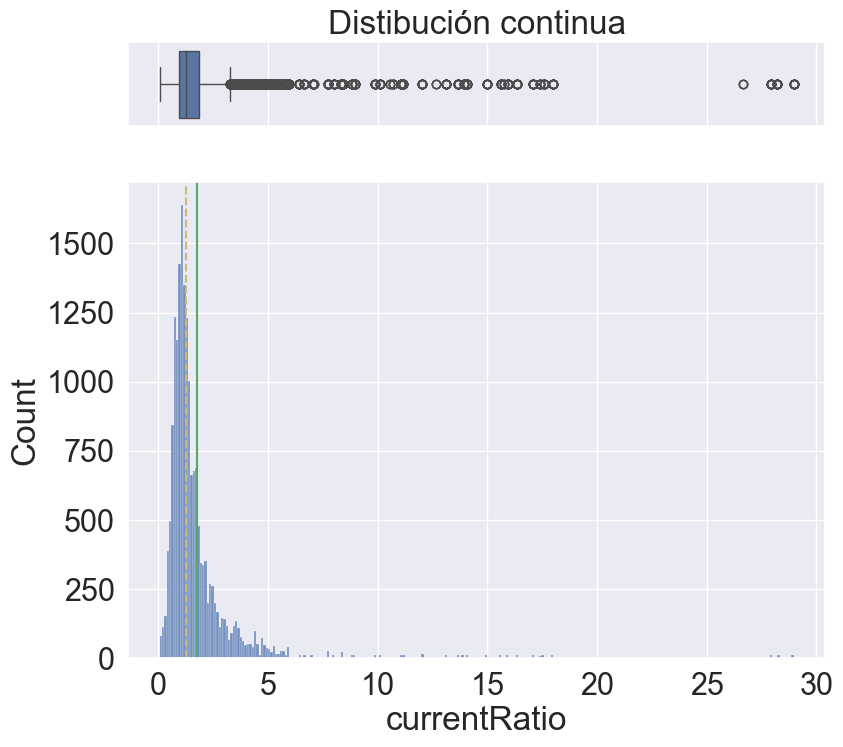

In [10]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [11]:
# Transformacion yeo-johnson sobre ratios de valuación
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['returnOnEquity', 'debtToEquity']
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_Transformed'] = pt.fit_transform(df_transformed[[columna]])
    # Elimino la columna sin transformar
    df_transformed.drop(columna, axis=1, inplace=True)

In [12]:
# Transformaciones logarítmicas
columnas_a_transformar = [
    'RelativeAssets', 
    'RelativeRevenue',
    'RelativeEquity', 
    'Close', 
    'currentRatio'
    ]
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_log'] = np.log1p(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew()

Monthly_Return                 1.613664
Monthly_Variance              11.544988
Market_Covariance              1.342297
MarketCap                      8.292212
EnterpriseValue                8.154344
PE_Trailing                  -39.429640
EnterpriseToEbitda            13.317868
PriceToBook                    8.215336
operatingMargins              -0.432521
profitMargins                 -1.912449
ReturnOnAssets                 0.690975
Revenue_YoY                    3.993464
Revenue_QoQ                    8.356580
EBITDA_YoY                   -12.949636
EBITDA_QoQ                   -24.281925
FCF_YoY                       25.420480
FCF_QoQ                       46.926445
Capex_YoY                    -36.081482
Capex_QoQ                    -73.339256
NetDebt_to_EBITDA              3.030180
FCF_to_EBITDA                 13.746321
Capex_to_Revenue               2.862817
TotalAssets                    3.693064
TotalRevenue                   5.112157
TotalEquity                    5.847092


In [13]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Monthly_Return              18028 non-null  float64
 1   Monthly_Variance            18028 non-null  float64
 2   Market_Covariance           18028 non-null  float64
 3   MarketCap                   18028 non-null  float64
 4   EnterpriseValue             18028 non-null  float64
 5   PE_Trailing                 18028 non-null  float64
 6   EnterpriseToEbitda          18028 non-null  float64
 7   PriceToBook                 18028 non-null  float64
 8   operatingMargins            18028 non-null  float64
 9   profitMargins               18028 non-null  float64
 10  ReturnOnAssets              18028 non-null  float64
 11  Revenue_YoY                 18028 non-null  float64
 12  Revenue_QoQ                 18028 non-null  float64
 13  EBITDA_YoY                  180

In [14]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = [
    'MarketCap', 
    'EnterpriseValue',
    'PE_Trailing',
    'EnterpriseToEbitda',
    'PriceToBook',
    'TotalAssets',
    'TotalRevenue',
    'TotalEquity', 
    'Date', 
    'Ticker', 
    'Close_log'    
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [15]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Monthly_Return
Monthly_Variance
Market_Covariance
operatingMargins
profitMargins
ReturnOnAssets
Revenue_YoY
Revenue_QoQ
EBITDA_YoY
EBITDA_QoQ
FCF_YoY
FCF_QoQ
Capex_YoY
Capex_QoQ
NetDebt_to_EBITDA
FCF_to_EBITDA
Capex_to_Revenue
returnOnEquity_Transformed
debtToEquity_Transformed
RelativeAssets_log
RelativeRevenue_log
RelativeEquity_log
currentRatio_log


In [16]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew()

Monthly_Return                0.477117
Monthly_Variance              1.753133
Market_Covariance             1.022996
operatingMargins              0.454687
profitMargins                 0.123065
ReturnOnAssets                0.567624
Revenue_YoY                   0.161943
Revenue_QoQ                  -2.140575
EBITDA_YoY                    0.438585
EBITDA_QoQ                   -0.224040
FCF_YoY                       0.683946
FCF_QoQ                      -1.544735
Capex_YoY                    -0.802554
Capex_QoQ                     0.233583
NetDebt_to_EBITDA             0.350941
FCF_to_EBITDA                -0.237955
Capex_to_Revenue              1.692649
returnOnEquity_Transformed   -0.000412
debtToEquity_Transformed      0.170461
RelativeAssets_log            1.733468
RelativeRevenue_log           1.649089
RelativeEquity_log            1.802564
currentRatio_log              1.258428
dtype: float64

Cont


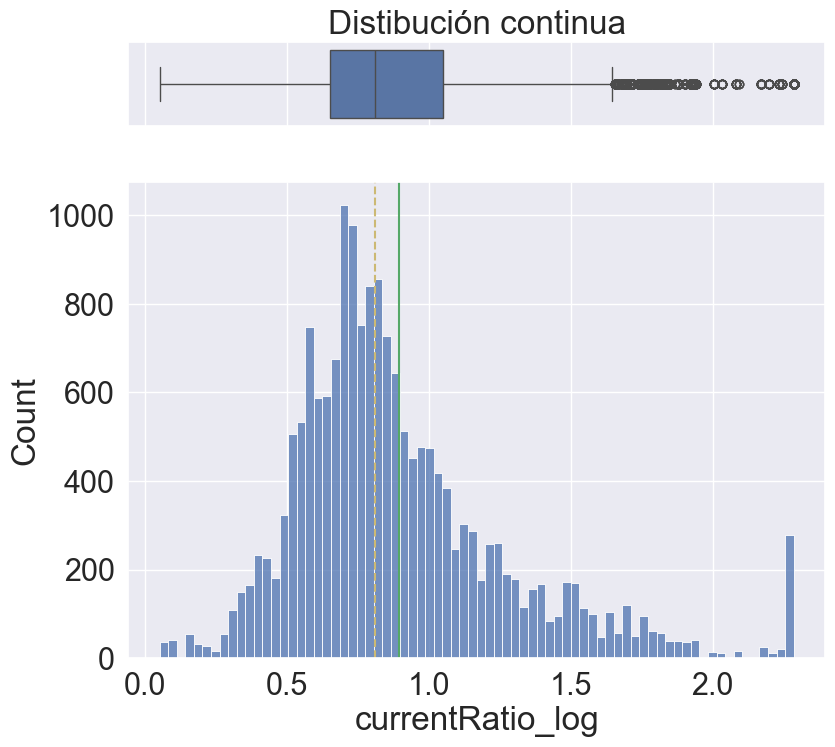

In [17]:
# Visualizar cambios
columna_a_graficar = 'currentRatio_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [18]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,18028.0,0.014198,0.089328,-0.342330,-0.039415,0.012182,0.061448,0.366073
Monthly_Variance,18028.0,0.007920,0.006293,-0.004676,0.003642,0.005987,0.009851,0.028485
Market_Covariance,18028.0,0.001648,0.001478,-0.003955,0.000644,0.001418,0.002389,0.007635
operatingMargins,18028.0,0.189334,0.141715,-0.398900,0.102500,0.177200,0.257600,0.741900
profitMargins,18028.0,0.134278,0.130781,-0.353200,0.065400,0.120100,0.195400,0.603100
ReturnOnAssets,18028.0,0.078489,0.077446,-0.227700,0.032300,0.062800,0.116600,0.388700
Revenue_YoY,18028.0,0.051086,0.105115,-0.269178,0.002831,0.045014,0.091580,0.358245
Revenue_QoQ,18028.0,0.000001,0.000016,-0.000056,0.000000,0.000000,0.000000,0.000020
EBITDA_YoY,18028.0,0.128172,0.350407,-0.816284,-0.015815,0.098550,0.250223,1.051589
EBITDA_QoQ,18028.0,0.000028,0.000134,-0.000284,0.000000,0.000000,0.000000,0.000237


# Variables Categoricas

In [19]:
df_cat_transformed = df_transformed_features.select_dtypes(exclude='number')

# Valores únicos
df_cat_transformed.nunique()

Sector        11
DateAdded    338
dtype: int64

In [20]:
# Convertir Sector a category
df_cat_transformed['Sector'] = df_cat_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_cat_transformed['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2881
HealthCare               2238
ConsumerDiscretionary    1900
ConsumerStaples          1466
Financials               1268
RealEstate               1209
Utilities                1174
Materials                1025
CommunicationServices     925
Energy                    819
Name: count, dtype: int64

In [21]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_cat_transformed['DateAdded'] = pd.to_datetime(df_cat_transformed['DateAdded'], errors='coerce')
df_cat_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_cat_transformed['DateAdded']).dt.days / 365.25), 0)
df_cat_transformed.drop('DateAdded', axis=1, inplace=True)

In [22]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_cat_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   MarketCap                   18028 non-null  float64 
 1   EnterpriseValue             18028 non-null  float64 
 2   PE_Trailing                 18028 non-null  float64 
 3   EnterpriseToEbitda          18028 non-null  float64 
 4   PriceToBook                 18028 non-null  float64 
 5   TotalAssets                 18028 non-null  float64 
 6   TotalRevenue                18028 non-null  float64 
 7   TotalEquity                 18028 non-null  float64 
 8   Date                        18028 non-null  object  
 9   Ticker                      18028 non-null  object  
 10  Close_log                   18028 non-null  float64 
 11  Sector                      18028 non-null  category
 12  YearsSinceAdded             18028 non-null  float64 
 13  Monthly_Return  

In [23]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")